In [14]:
# Created the modules that will be used:

from pathlib import Path

from mpi4py import MPI
from petsc4py.PETSc import ScalarType

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from mpl_toolkits.mplot3d import Axes3D

import ufl
from dolfinx import fem, io, mesh, plot
from dolfinx.fem.petsc import LinearProblem
from dolfinx.plot import vtk_mesh

In [15]:
# Create the mesh and Element space

msh = mesh.create_rectangle(
    comm = MPI.COMM_WORLD,
    points = ((0.0, 0.0), (2.0, 1.0)),
    n = (32, 16),
    cell_type = mesh.CellType.triangle, 
)

V = fem.functionspace(msh, ("Lagrange", 1))

In [16]:
# Boundary Condition

tdim = msh.topology.dim
fdim = tdim - 1
facets = mesh.locate_entities_boundary(
    msh,
    dim = fdim,
    marker = lambda x: np.isclose(x[0], 0.0) | np.isclose(x[0], 2.0)
)

In [17]:
# Degree-of-freedom

dofs = fem.locate_dofs_topological(V=V, entity_dim=fdim, entities=facets)

In [18]:
#Boundary Condition:

bc = fem.dirichletbc(value=ScalarType(0), dofs=dofs, V=V)

In [19]:
#Variational problem

u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)
x = ufl.SpatialCoordinate(msh)
f = 10 * ufl.exp(-((x[0] - 0.5) ** 2 + (x[1] - 0.5)**2)/0.02)
g = ufl.sin(5 * x[0])
a = ufl.inner(ufl.grad(u), ufl.grad(v)) * ufl.dx
L = ufl.inner(f, v) * ufl.dx + ufl.inner(g, v) * ufl.ds

In [20]:
#Linear Problem

problem = LinearProblem(
    a,
    L,
    petsc_options_prefix="demo_poisson_",
    petsc_options={"ksp_type": "preonly", "pc_type": "lu", "ksp_error_if_not_converged": True}
)
uh = problem.solve()
assert isinstance(uh, fem.Function)

In [21]:
#The solution can be written to a XDMFile to use in ParaView or Vislt
out_folder = Path("out_poisson")
out_folder.mkdir(parents=True, exist_ok=True)
with io.XDMFFile(msh.comm, out_folder / "poisson.xdmf", "w") as file:
    file.write_mesh(msh)
    file.write_function(uh)

In [22]:
# The solution can be visualised with PyVista

try:
    import pyvista
    from dolfinx import plot

    # Create VTK mesh from the mesh
    topology, cell_types, geometry = plot.vtk_mesh(msh)

    # Create PyVista grid
    grid = pyvista.UnstructuredGrid(
        topology,
        cell_types,
        geometry
    )

    # Add the solution to the grid
    grid.point_data["u"] = uh.x.array.real

    # Create plotter
    plotter = pyvista.Plotter()

    # Add the solution
    plotter.add_mesh(
        grid,
        show_edges=True
    )

    # Warp the mesh according to the solution
    warped = grid.warp_by_scalar("u")

    plotter.add_mesh(
        warped,
        show_edges=True
    )

    # Show or save the figure
    if pyvista.OFF_SCREEN:
        plotter.screenshot(out_folder / "uh_poisson.png")
    else:
        plotter.show()

except ModuleNotFoundError:
    print("'pyvista' is required to visualise the solution.")
    print("To install pyvista with pip: 'python3 -m pip install pyvista'.")

Widget(value='<iframe src="http://localhost:39127/index.html?ui=P_0x7e35a48b1e50_1&reconnect=auto" class="pyvi…

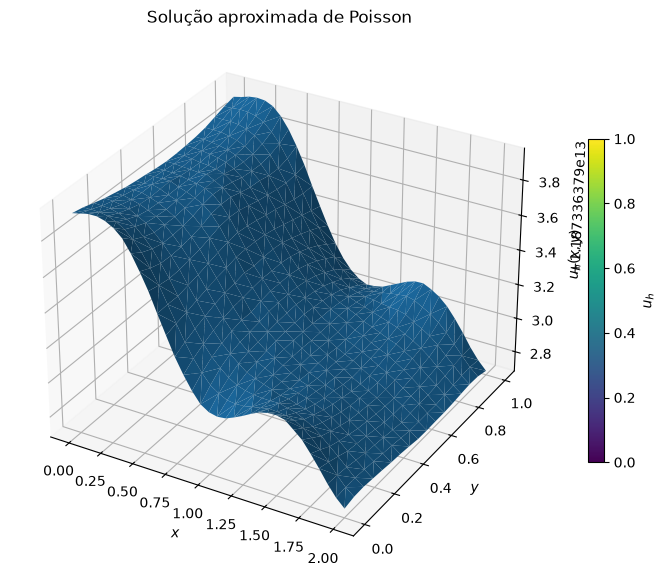

In [23]:

x = msh.geometry.x[:, 0]
y = msh.geometry.x[:, 1]
u = uh.x.array.real

triangulation = tri.Triangulation(x, y)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_trisurf(
    triangulation,
    u,
)

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$u_h(x,y)$")
ax.set_title("Solução aproximada de Poisson")

fig.colorbar(surf, ax=ax, shrink=0.6, label="$u_h$")

plt.show()

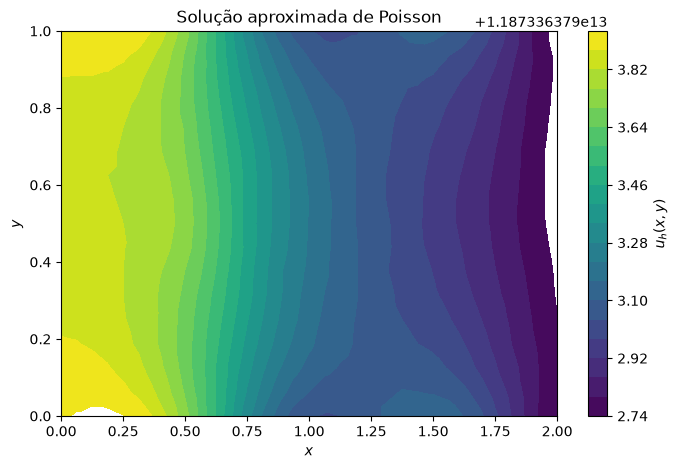

In [24]:
plt.figure(figsize=(8, 5))

plt.tricontourf(
    triangulation,
    u,
    levels=20
)

plt.colorbar(label="$u_h(x,y)$")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Solução aproximada de Poisson")

plt.show()

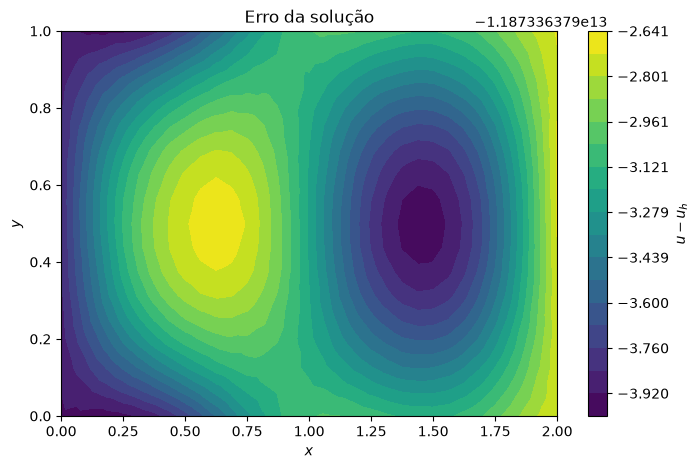

In [25]:
x = msh.geometry.x[:, 0]
y = msh.geometry.x[:, 1]

# Solução exata
u_exact = np.sin(np.pi * x) * np.sin(np.pi * y)

# Solução numérica
u_num = uh.x.array.real

# Erro
error = u_exact - u_num

# Triangulação
triangulation = tri.Triangulation(x, y)

# Gráfico do erro
plt.figure(figsize=(8, 5))

plt.tricontourf(
    triangulation,
    error,
    levels=20
)

plt.colorbar(label="$u-u_h$")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Erro da solução")

plt.show()